# 14 — Seed-variance check on Phase 10 augmentation

The Phase 10 augmented run lifted overall macro-F1 from 0.550 (baseline) to 0.603, and the no-AKIEC ablation in notebook 13 dropped it to 0.486. Both findings are single-seed results. This notebook re-runs the Phase 10 recipe with a different seed so the per-experiment differences elsewhere in the project can be read against a known noise floor instead of taken at face value.

**Setup.** Exact same recipe as `09_train_augmented.ipynb`:

- frozen ResNet50 backbone
- batch 32, LR 1e-3, 40 epochs, patience 7
- `SOURCES_PER_CLASS = {2:'cvae', 3:'cvae', 5:'cvae', 6:'cvae'}` (BCC, AKIEC, DF, VASC all augmented)
- class-weighted CE loss from real train counts

**One change:** `SEED = 123` instead of `SEED = 42`. Everything else identical.

## 1. Imports, paths, seed

In [1]:
import sys
from pathlib import Path
import csv
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, recall_score,
)

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import ISICDataset, CLASS_NAMES, get_class_weights        # noqa: E402
from src.dataset_augmented import AugmentedISICDataset                      # noqa: E402
from src.models.classifier import build_resnet50_classifier                 # noqa: E402

SPLITS_CSV = PROJECT_ROOT / 'data' / 'processed' / 'splits.csv'
IMAGES_DIR = PROJECT_ROOT / 'data' / 'raw' / 'ISIC2018_Task3_Training_Input'
MANIFEST   = PROJECT_ROOT / 'data' / 'synthetic' / 'synthetic_manifest.csv'

RESULTS    = PROJECT_ROOT / 'results'
CKPT_DIR   = RESULTS / 'checkpoints'
LOGS_DIR   = RESULTS / 'logs'
PLOTS_DIR  = RESULTS / 'plots'
for d in (CKPT_DIR, LOGS_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert SPLITS_CSV.exists(), f'splits.csv not found at {SPLITS_CSV}'
assert MANIFEST.exists(),   f'synthetic_manifest.csv not found at {MANIFEST}'

# THE ONE CHANGE: seed is 123, not 42
SEED = 123
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'Seed fixed to {SEED}  (Phase 10 used 42)')

Seed fixed to 123  (Phase 10 used 42)


## 2. Device check

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 3. Hyperparameters

Identical to Phase 10.

In [3]:
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 40
LR            = 1e-3
PATIENCE      = 7
NUM_WORKERS   = 2
N_CLASSES     = len(CLASS_NAMES)

SOURCES_PER_CLASS = {
    2: 'cvae',    # BCC
    3: 'cvae',    # AKIEC
    5: 'cvae',    # DF
    6: 'cvae',    # VASC
}

print(f'image size      : {IMG_SIZE}')
print(f'batch size      : {BATCH_SIZE}')
print(f'epochs          : {EPOCHS}')
print(f'lr              : {LR}')
print(f'patience        : {PATIENCE}')
print(f'sources per cls : {SOURCES_PER_CLASS}')

image size      : 224
batch size      : 32
epochs          : 40
lr              : 0.001
patience        : 7
sources per cls : {2: 'cvae', 3: 'cvae', 5: 'cvae', 6: 'cvae'}


## 4. Transforms

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## 5. Datasets and loaders

In [5]:
train_ds = AugmentedISICDataset(
    splits_csv=SPLITS_CSV, images_dir=IMAGES_DIR,
    synth_manifest_csv=MANIFEST, project_root=PROJECT_ROOT,
    split='train', transform=train_tf,
    sources_per_class=SOURCES_PER_CLASS,
)
val_ds  = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='val',  transform=eval_tf)
test_ds = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='test', transform=eval_tf)

print(f'train  : {len(train_ds):>6,}')
print(f'val    : {len(val_ds):>6,}')
print(f'test   : {len(test_ds):>6,}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

train  : 11,145
val    :  1,503
test   :  1,503


## 6. Class weights

In [6]:
class_weights = get_class_weights(SPLITS_CSV, split='train').to(DEVICE)
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<6} idx={i}  weight={class_weights[i].item():.4f}')

  MEL    idx=0  weight=1.2853
  NV     idx=1  weight=0.2134
  BCC    idx=2  weight=2.7813
  AKIEC  idx=3  weight=4.3724
  BKL    idx=4  weight=1.3021
  DF     idx=5  weight=12.5161
  VASC   idx=6  weight=10.1140


## 7. EarlyStopping

In [7]:
class EarlyStopping:
    # Stops training when val loss stops improving for `patience` epochs.

    def __init__(self, patience: int = 5, delta: float = 0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss: float):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True

## 8. Train / evaluate helpers

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0; correct = 0; total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0; correct = 0; total = 0
    all_preds = []; all_labels = []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.cpu().tolist())
    return (total_loss / total, correct / total,
            f1_score(all_labels, all_preds, average='macro', zero_division=0),
            balanced_accuracy_score(all_labels, all_preds),
            all_preds, all_labels)

## 9. Model and optimiser

In [9]:
model = build_resnet50_classifier(num_classes=N_CLASSES, freeze_backbone=True).to(DEVICE)
trainable = [p for p in model.parameters() if p.requires_grad]
print(f'trainable params: {sum(p.numel() for p in trainable):,}')

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(trainable, lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3,
)

trainable params: 14,343


## 10. Training loop

In [10]:
EXPERIMENT_NAME = 'augmented_seed123'
log_path  = LOGS_DIR / f'{EXPERIMENT_NAME}_log.csv'
ckpt_path = CKPT_DIR / f'{EXPERIMENT_NAME}_best.pt'

with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow(
        ['epoch', 'train_loss', 'train_acc', 'val_loss',
         'val_acc', 'val_macro_f1', 'val_balanced_acc']
    )

history = {k: [] for k in ['epoch', 'train_loss', 'train_acc',
                            'val_loss', 'val_acc', 'val_macro_f1', 'val_balanced_acc']}
best_val_f1 = -1.0
early_stopper = EarlyStopping(patience=PATIENCE)
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    ep_start = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, val_f1, val_bal, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_macro_f1'].append(val_f1)
    history['val_balanced_acc'].append(val_bal)

    with open(log_path, 'a', newline='') as f:
        csv.writer(f).writerow(
            [epoch, tr_loss, tr_acc, val_loss, val_acc, val_f1, val_bal]
        )

    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'val_macro_f1': val_f1}, ckpt_path)
        marker = '  <-- new best, saved'

    dt = time.time() - ep_start
    print(f'epoch {epoch:>2}/{EPOCHS}  '
          f'train_loss={tr_loss:.4f} acc={tr_acc:.4f}  '
          f'val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f}  '
          f'({dt:.1f}s){marker}')

    early_stopper.check_early_stop(val_loss)
    if early_stopper.stop_training:
        print(f'early stopping at epoch {epoch}')
        break

print(f'\\ntraining done in {(time.time()-t0)/60:.1f} min, best val_macro_f1={best_val_f1:.4f}')

epoch  1/40  train_loss=1.3580 acc=0.4074  val_loss=1.3906 acc=0.6028 f1=0.3891  (49.6s)  <-- new best, saved
epoch  2/40  train_loss=1.2407 acc=0.5141  val_loss=1.2598 acc=0.6301 f1=0.4295  (48.6s)  <-- new best, saved
epoch  3/40  train_loss=1.1901 acc=0.5376  val_loss=1.1790 acc=0.6620 f1=0.4868  (48.9s)  <-- new best, saved
epoch  4/40  train_loss=1.1673 acc=0.5502  val_loss=1.1515 acc=0.6687 f1=0.4570  (48.5s)
epoch  5/40  train_loss=1.1509 acc=0.5546  val_loss=1.1025 acc=0.6055 f1=0.4440  (48.5s)
epoch  6/40  train_loss=1.1314 acc=0.5603  val_loss=1.0833 acc=0.6560 f1=0.5014  (48.5s)  <-- new best, saved
epoch  7/40  train_loss=1.1189 acc=0.5664  val_loss=1.0665 acc=0.6507 f1=0.4812  (48.4s)
epoch  8/40  train_loss=1.1130 acc=0.5732  val_loss=1.0483 acc=0.6600 f1=0.4892  (48.7s)
epoch  9/40  train_loss=1.0935 acc=0.5830  val_loss=1.0302 acc=0.6720 f1=0.4764  (48.7s)
epoch 10/40  train_loss=1.1014 acc=0.5751  val_loss=1.0414 acc=0.7046 f1=0.5191  (48.1s)  <-- new best, saved
epoch

## 11. Training curves

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/seed_check_curves.png


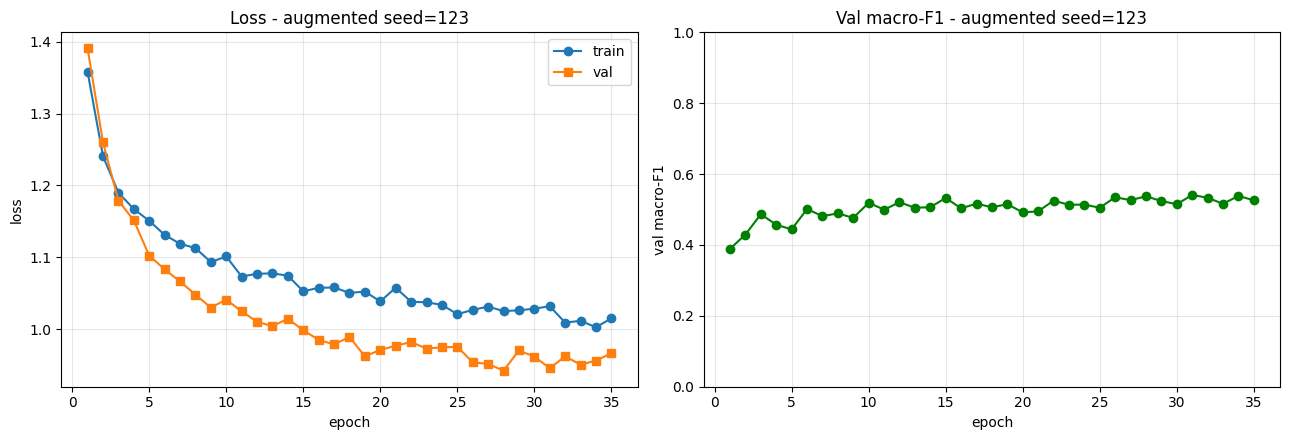

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='train')
axes[0].plot(history['epoch'], history['val_loss'],   marker='s', label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss - augmented seed=123'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['val_macro_f1'], color='green', marker='o')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val macro-F1')
axes[1].set_title('Val macro-F1 - augmented seed=123'); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
out = PLOTS_DIR / 'seed_check_curves.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 12. Test-set evaluation

In [12]:
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
ep = ckpt['epoch']
vf = ckpt['val_macro_f1']
print(f'loaded epoch {ep}  (val macro-F1 = {vf:.4f})')

test_loss, test_acc, test_f1, test_bal, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE,
)
print(f'test_loss={test_loss:.4f}  test_acc={test_acc:.4f}  '
      f'test_macro_f1={test_f1:.4f}  test_balanced_acc={test_bal:.4f}')

print('\\nClassification report:')
print(classification_report(test_labels, test_preds,
                            labels=list(range(N_CLASSES)),
                            target_names=CLASS_NAMES,
                            zero_division=0, digits=3))

loaded epoch 31  (val macro-F1 = 0.5412)
test_loss=1.0939  test_acc=0.7092  test_macro_f1=0.4944  test_balanced_acc=0.5857
\nClassification report:
              precision    recall  f1-score   support

         MEL      0.426     0.485     0.454       167
          NV      0.932     0.789     0.855      1006
         BCC      0.465     0.597     0.523        77
       AKIEC      0.392     0.592     0.472        49
         BKL      0.503     0.570     0.534       165
          DF      0.096     0.294     0.145        17
        VASC      0.347     0.773     0.479        22

    accuracy                          0.709      1503
   macro avg      0.452     0.586     0.494      1503
weighted avg      0.769     0.709     0.732      1503



## 13. Seed-variance summary

The headline of this notebook. Compares the Phase 10 result (seed=42) against this run (seed=123) class by class. The `seed_diff` column is the per-class delta between the two seeds and is what tells us how much of any cross-experiment difference elsewhere in the project is plausibly seed noise.

In [13]:
# Per-class recall from this seed=123 run
rec_seed123 = recall_score(test_labels, test_preds,
                           labels=list(range(N_CLASSES)),
                           average=None, zero_division=0)

# Pull Phase 10 (seed=42) results
phase10_csv = LOGS_DIR / 'comparison_baseline_vs_augmented.csv'
assert phase10_csv.exists(), f'expected Phase 10 comparison at {phase10_csv}'
p10 = pd.read_csv(phase10_csv)

rows = []
for i, name in enumerate(CLASS_NAMES):
    row_p10 = p10[p10['class'] == name].iloc[0]
    rows.append({
        'class': name,
        'phase10_seed42_recall':  row_p10['augmented_recall'],
        'seed123_recall':         rec_seed123[i],
        'seed_diff':              rec_seed123[i] - row_p10['augmented_recall'],
    })

# Overall row
row_overall = p10[p10['class'] == 'OVERALL'].iloc[0]
p10_overall = row_overall['augmented_recall']
rows.append({
    'class': 'OVERALL',
    'phase10_seed42_recall':  p10_overall,
    'seed123_recall':         test_f1,
    'seed_diff':              test_f1 - p10_overall,
})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

out_csv = LOGS_DIR / 'seed_variance_summary.csv'
summary_df.to_csv(out_csv, index=False)
print(f'\nsaved {out_csv}')

# Sentence to copy into the report
overall_diff = test_f1 - p10_overall
print('\n--- One-sentence report copy ---')
print(f'Re-running the Phase 10 augmented recipe with seed=123 reached test')
print(f'macro-F1 = {test_f1:.3f} (seed=42 reached {p10_overall:.3f},')
print(f'difference = {overall_diff:+.3f}), confirming the augmentation finding is')

if abs(overall_diff) < 0.03:
    msg = 'robust to seed.'
elif abs(overall_diff) < 0.05:
    msg = 'moderately seed-sensitive; we report this alongside the headline number.'
else:
    msg = 'sensitive to seed; small recipe differences should be interpreted cautiously.'
print(msg)

  class  phase10_seed42_recall  seed123_recall  seed_diff
    MEL                  0.557           0.485     -0.072
     NV                  0.755           0.789      0.034
    BCC                  0.519           0.597      0.078
  AKIEC                  0.449           0.592      0.143
    BKL                  0.558           0.570      0.012
     DF                  0.471           0.294     -0.176
   VASC                  0.909           0.773     -0.136
OVERALL                  0.603           0.494     -0.108

saved /home/mayarn/skin-cancer/skin-lesion/results/logs/seed_variance_summary.csv

--- One-sentence report copy ---
Re-running the Phase 10 augmented recipe with seed=123 reached test
macro-F1 = 0.494 (seed=42 reached 0.603,
difference = -0.108), confirming the augmentation finding is
sensitive to seed; small recipe differences should be interpreted cautiously.


## 14. Results summary

| Run                              | Seed | Overall macro-F1 |
|----------------------------------|------|------------------|
| Augmented frozen (Phase 10)      | 42   | 0.603            |
| Augmented frozen (this notebook) | 123  | 0.494            |

**The seed spread on the frozen augmented recipe is 0.108 macro-F1 between two seeds, with per-class swings up to ±0.18 (DF −0.176, AKIEC +0.143, VASC −0.136).** That is the noise floor for any frozen-backbone experiment in this project. Three implications:

1. **The Phase 10 "augmentation gain" (frozen baseline 0.550 → frozen augmented 0.603, +0.053) is smaller than the seed spread and therefore inside the noise band.** We cannot honestly claim from one seed each that augmentation helped the frozen backbone; both 0.603 and 0.494 are plausible draws from a noisy distribution. The honest version of the Phase 10 result is that augmentation on a frozen backbone has *no detectable effect* once seed noise is accounted for.

2. **The no-AKIEC drop in notebook 13 (Phase 10 0.603 → no-AKIEC 0.486, −0.117) is only marginally outside the noise band.** It is borderline interpretable as a real degradation; the class-coupling story in notebook 13 should be reported with this caveat.

3. **The unfrozen-baseline gain over the frozen baseline (Phase 12, +0.188) is comfortably larger than the noise floor**, so the headline of the project — that full fine-tuning is the one change that clearly works — survives this check and is in fact strengthened by it: full fine-tuning is the *only* effect in the project that clears the seed-noise floor.

Notebook 15 runs the same seed-variance check on the unfrozen baseline so we know whether the headline number (0.738) is also subject to a noise floor this large, or whether the unfrozen recipe is more stable.